# Downgrade quality: synthetic power-law map

This notebook compares `ud_grade`, `harmonic_ud_grade`, and `smoothing + ud_grade` on a synthetic power-law sky.

Quality is measured against a direct reference map synthesized at the target pixelization from the same input spectrum realization. The default `harmonic_ud_grade` setting now uses `lmax = 3*nside_out - 1`, so the notebook shows a single harmonic downgrade curve.

In [1]:
from pathlib import Path
import urllib.request

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt


In [2]:
def _round_sig(x, sig=2):
    if x == 0 or not np.isfinite(x):
        return float(x)
    return float(np.round(x, sig - int(np.floor(np.log10(abs(x)))) - 1))

def rounded_limits(*maps, q=(0.5, 99.5)):
    vals = np.concatenate([m[np.isfinite(m)] for m in maps])
    lo, hi = np.percentile(vals, q)
    vmin = _round_sig(float(lo), sig=2)
    vmax = _round_sig(float(hi), sig=2)
    if vmin == vmax:
        vmax = vmin + 1.0
    return vmin, vmax

def proj_panels(maps, titles, cmap='RdBu_r', q=(0.5, 99.5), ncol=3, xsize=2200, symmetric=False):
    vmin, vmax = rounded_limits(*maps, q=q)
    if symmetric:
        lim = max(abs(vmin), abs(vmax))
        vmin, vmax = -lim, lim
    print(f'vmin={vmin}, vmax={vmax}')
    n = len(maps)
    ncol = min(ncol, n)
    nrow = int(np.ceil(n / ncol))
    plt.figure(figsize=(6.8*ncol, 4.8*nrow))
    for i, (m, t) in enumerate(zip(maps, titles), start=1):
        hp.projview(
            m,
            sub=(nrow, ncol, i),
            title=t,
            min=vmin,
            max=vmax,
            cmap=cmap,
            graticule=True,
            xsize=xsize,
            cb_orientation='horizontal',
        )
    plt.tight_layout()

def compare_to_ref(m, m_ref, cl, cl_ref, ell_min=2):
    good = np.isfinite(m) & np.isfinite(m_ref)
    m0 = m[good]
    r0 = m_ref[good]
    rmse_rel = np.sqrt(np.mean((m0-r0)**2)) / np.std(r0)
    mae_rel = np.mean(np.abs(m0-r0)) / np.std(r0)
    corr = np.corrcoef(m0, r0)[0, 1]
    spec_rel_l2 = np.linalg.norm(cl[ell_min:] - cl_ref[ell_min:]) / np.linalg.norm(cl_ref[ell_min:])
    return {
        'rmse_rel_std': float(rmse_rel),
        'mae_rel_std': float(mae_rel),
        'map_corr': float(corr),
        'spec_rel_l2': float(spec_rel_l2),
    }

def moll_diff_panels(diff_maps, titles, unit='', q=(0.2, 99.8)):
    vmin, vmax = rounded_limits(*diff_maps, q=q)
    lim = max(abs(vmin), abs(vmax))
    vmin, vmax = -lim, lim
    print(f'moll diff scale: vmin={vmin}, vmax={vmax}')
    n = len(diff_maps)
    fig = plt.figure(figsize=(6.8*n, 5.0))
    for i, (m, t) in enumerate(zip(diff_maps, titles), start=1):
        hp.mollview(
            m,
            fig=fig.number,
            sub=(1, n, i),
            title=t,
            min=vmin,
            max=vmax,
            cmap='RdBu_r',
            unit=unit,
            cbar=True,
        )
    plt.tight_layout()


## 1) Synthetic power-law map with reference at target NSIDE

In [3]:
nside_in = 256
nside_out = 32
lmax_in = 3 * nside_in - 1
lmax_out = 3 * nside_out - 1

ell = np.arange(lmax_in + 1)
cl = np.zeros(lmax_in + 1)
cl[2:] = (ell[2:] / 80.0) ** (-2.7)
cl /= cl[80]

np.random.seed(1234)
alm_in = hp.synalm(cl, lmax=lmax_in)
m_in = hp.alm2map(alm_in, nside=nside_in, lmax=lmax_in, pixwin=False)

# Reference map: directly synthesize at output NSIDE from the same realization
alm_ref = hp.resize_alm(alm_in, lmax_in, lmax_in, lmax_out, lmax_out)
m_ref = hp.alm2map(alm_ref, nside=nside_out, lmax=lmax_out, pixwin=False)

In [4]:
m_ud = hp.ud_grade(m_in, nside_out=nside_out)
m_harm = hp.harmonic_ud_grade(m_in, nside_out=nside_out)
m_smooth_ud = hp.ud_grade(hp.smoothing(m_in, fwhm=np.radians(30/60)), nside_out=nside_out)

vmin=-370.0, vmax=350.0


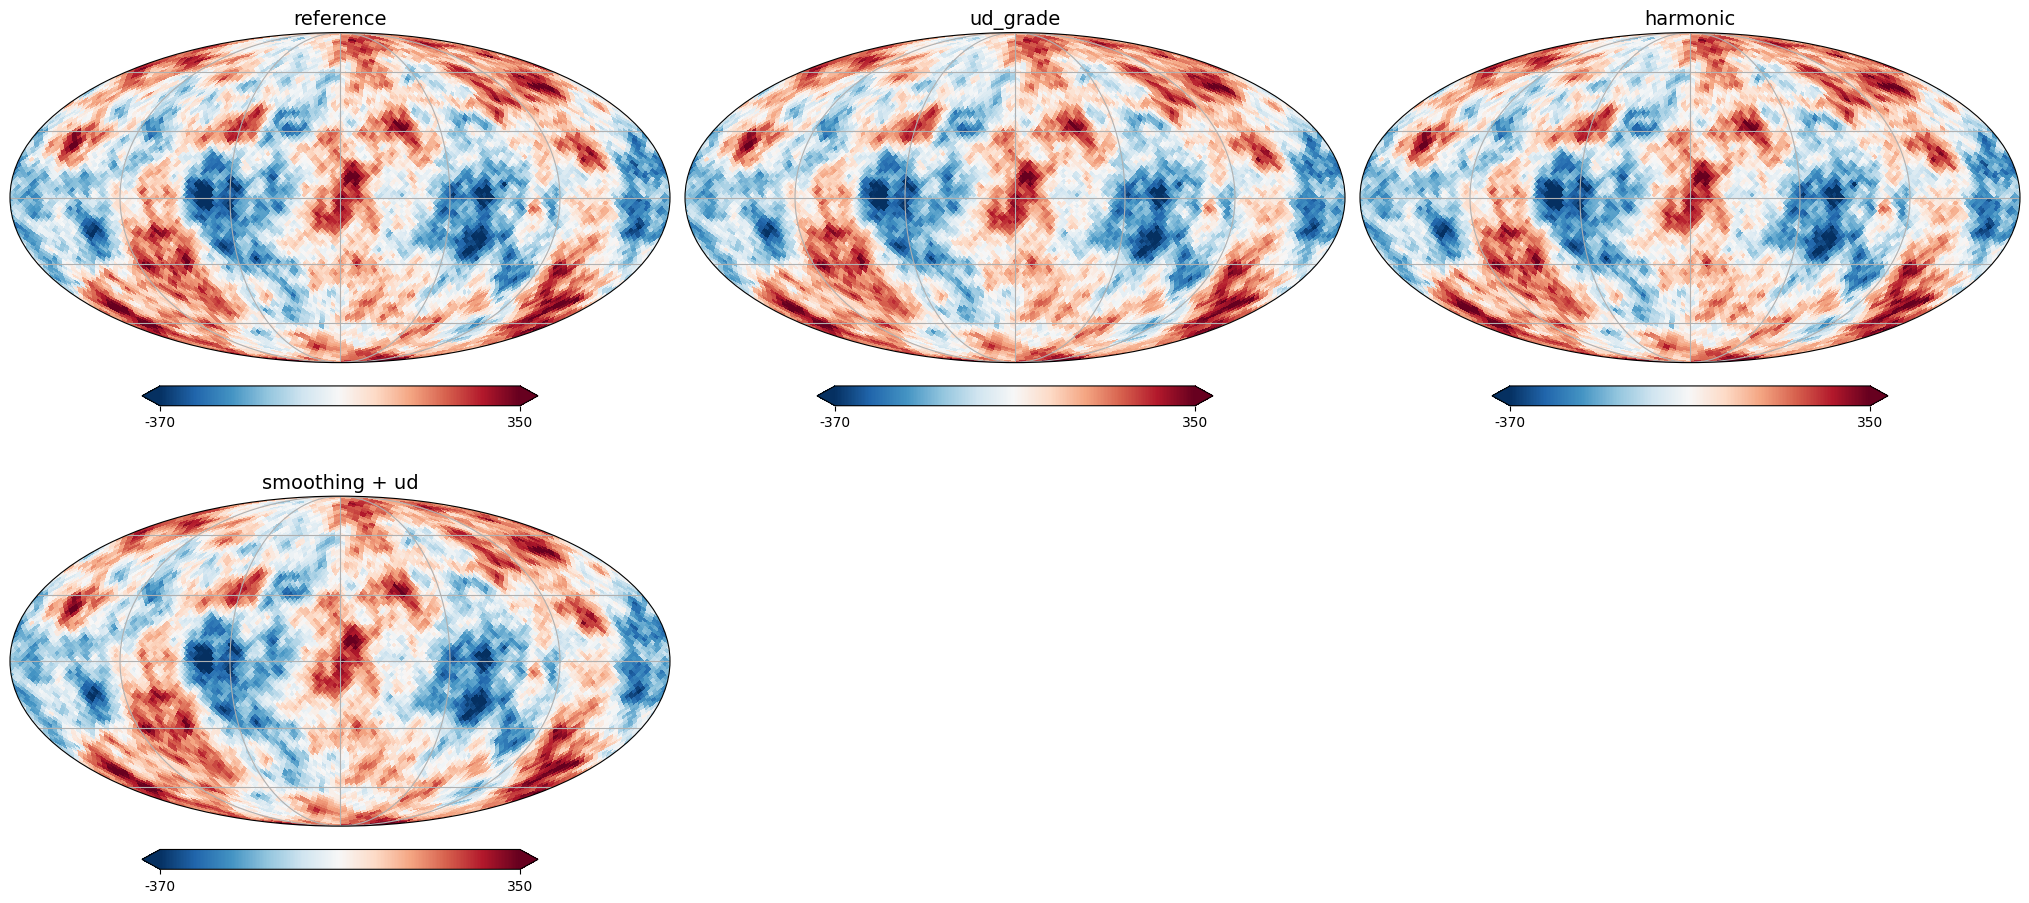

In [5]:
proj_panels(
    [m_ref, m_ud, m_harm, m_smooth_ud],
    ['reference', 'ud_grade', 'harmonic', 'smoothing + ud'],
    cmap='RdBu_r',
    q=(0.5, 99.5),
)

moll diff scale: vmin=-29.0, vmax=29.0


/tmp/ipykernel_12619/160289878.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


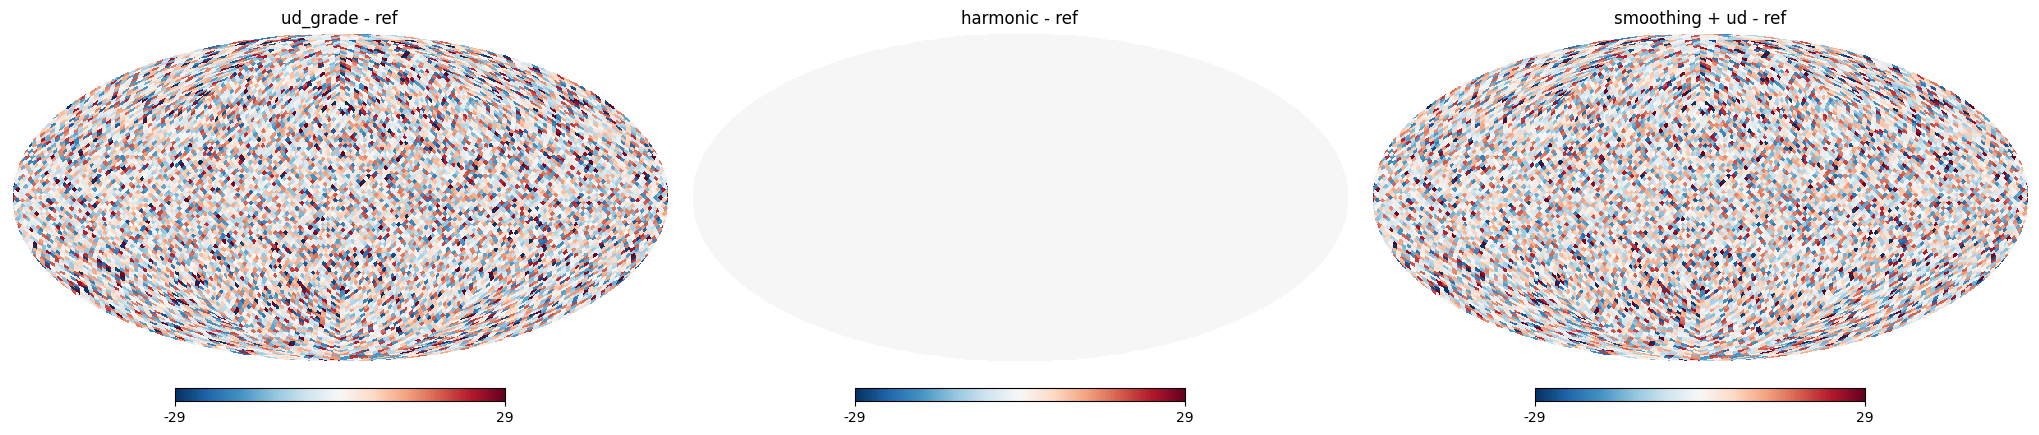

In [6]:
# Plot the difference maps with reference using the same scale as proj_panels
m_diff_ud = m_ud - m_ref
m_diff_harm = m_harm - m_ref
m_diff_smooth_ud = m_smooth_ud - m_ref

diff_maps = [m_diff_ud, m_diff_harm, m_diff_smooth_ud]
diff_titles = ['ud_grade - ref', 'harmonic - ref', 'smoothing + ud - ref']
# Use the same quantile scale as proj_panels (q=(0.5, 99.5))
moll_diff_panels(diff_maps, diff_titles, unit='', q=(0.5, 99.5))

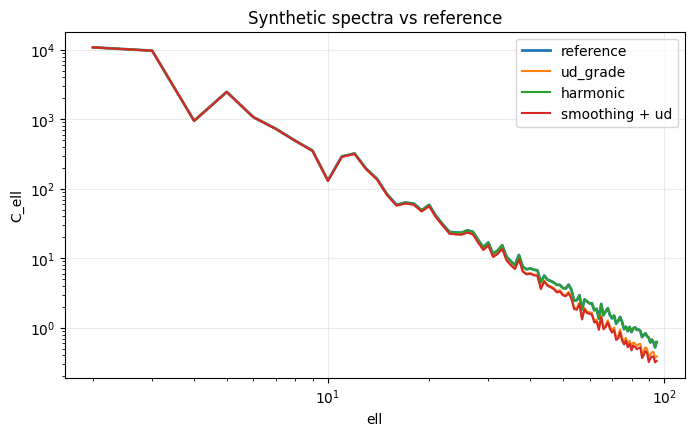

In [7]:
cl_ref = hp.anafast(m_ref, lmax=lmax_out)
cl_ud = hp.anafast(m_ud, lmax=lmax_out)
cl_harm = hp.anafast(m_harm, lmax=lmax_out)
cl_smooth_ud = hp.anafast(m_smooth_ud, lmax=lmax_out)
ell_out = np.arange(lmax_out + 1)

plt.figure(figsize=(8,4.5))
plt.loglog(ell_out[2:], cl_ref[2:], label='reference', lw=2)
plt.loglog(ell_out[2:], cl_ud[2:], label='ud_grade')
plt.loglog(ell_out[2:], cl_harm[2:], label='harmonic')
plt.loglog(ell_out[2:], cl_smooth_ud[2:], label='smoothing + ud')
plt.xlabel('ell')
plt.ylabel('C_ell')
plt.title('Synthetic spectra vs reference')
plt.grid(alpha=0.25)
plt.legend()

In [8]:
synthetic_metrics = {
    'ud_grade': compare_to_ref(m_ud, m_ref, cl_ud, cl_ref),
    'harmonic': compare_to_ref(m_harm, m_ref, cl_harm, cl_ref),
    'smoothing_plus_ud': compare_to_ref(m_smooth_ud, m_ref, cl_smooth_ud, cl_ref),
}
synthetic_metrics

{'ud_grade': {'rmse_rel_std': 0.08218301096181008,
  'mae_rel_std': 0.06568930677561473,
  'map_corr': 0.9966403616566285,
  'spec_rel_l2': 0.001212512369977117},
 'harmonic': {'rmse_rel_std': 2.6510262908937536e-06,
  'mae_rel_std': 6.314976076129644e-07,
  'map_corr': 0.9999999999964863,
  'spec_rel_l2': 1.291727421683854e-08},
 'smoothing_plus_ud': {'rmse_rel_std': 0.0796368528307676,
  'mae_rel_std': 0.06364785571496083,
  'map_corr': 0.9968654124092141,
  'spec_rel_l2': 0.0013864325413851188}}

## Synthetic quality metrics (Matplotlib)
**Scope:** these scalar metrics are computed **only for the synthetic power-law experiment** (Section 1), where a known target-NSIDE truth map exists.

This section summarizes how each downgrade method matches the direct target-NSIDE reference map. All metrics are computed against that reference and shown as an absolute matrix of bars.

**Definition of `ref` used below**

- `ref` means the synthetic target-NSIDE map built directly from the same realization, i.e. `m_ref` from `alm_ref`.
- In pixel-space metrics, `ref` is `m_ref` evaluated on the same valid pixels as the test map.
- In spectrum-space metrics, `ref` is `cl_ref = hp.anafast(m_ref, lmax=lmax_out)`.
- In `std(ref)`, the denominator is `np.std(m_ref[good])`, where `good` is the finite-pixel mask used for the method map and `m_ref`.

### What each statistic means

- `RMSE / std(ref)`: `sqrt(mean((m - m_ref)^2)) / std(m_ref)` on valid pixels. Lower is better.
- `MAE / std(ref)`: `mean(abs(m - m_ref)) / std(m_ref)` on valid pixels. Lower is better.
- `relative spectrum L2`: `||cl - cl_ref||_2 / ||cl_ref||_2` from `ell=2` to `lmax_out`. Lower is better.
- `1 - map correlation`: `1 - corr(m, m_ref)` on valid pixels. Lower is better.

In [9]:
method_order = ['harmonic', 'smoothing_plus_ud', 'ud_grade']
method_labels = {
    'harmonic': 'harmonic',
    'smoothing_plus_ud': 'smoothing + ud_grade',
    'ud_grade': 'ud_grade',
}

metric_labels = {
    'rmse_rel_std': 'RMSE / std(ref)',
    'mae_rel_std': 'MAE / std(ref)',
    'spec_rel_l2': 'relative spectrum L2',
    'one_minus_corr': '1 - map correlation',
}

metrics_plot = {}
for method, vals in synthetic_metrics.items():
    metrics_plot[method] = {
        'rmse_rel_std': vals['rmse_rel_std'],
        'mae_rel_std': vals['mae_rel_std'],
        'spec_rel_l2': vals['spec_rel_l2'],
        'one_minus_corr': 1.0 - vals['map_corr'],
    }

metric_order = ['rmse_rel_std', 'mae_rel_std', 'spec_rel_l2', 'one_minus_corr']

print('Synthetic metrics vs direct reference (lower is better):')
for method in method_order:
    row = ', '.join(
        f"{metric_labels[m]}={metrics_plot[method][m]:.3e}" for m in metric_order
    )
    print(f"  {method_labels[method]}: {row}")

Synthetic metrics vs direct reference (lower is better):
  harmonic: RMSE / std(ref)=2.651e-06, MAE / std(ref)=6.315e-07, relative spectrum L2=1.292e-08, 1 - map correlation=3.514e-12
  smoothing + ud_grade: RMSE / std(ref)=7.964e-02, MAE / std(ref)=6.365e-02, relative spectrum L2=1.386e-03, 1 - map correlation=3.135e-03
  ud_grade: RMSE / std(ref)=8.218e-02, MAE / std(ref)=6.569e-02, relative spectrum L2=1.213e-03, 1 - map correlation=3.360e-03


### Absolute metrics matrix

This matrix shows absolute values of each metric for each method on a log y-scale, always relative to `ref` (`m_ref` and `cl_ref` as defined above).

- Interpretation: compare bars within each panel; shorter bars indicate better agreement with `ref`.
- Why log scale: values can differ by orders of magnitude.
- Use this matrix to assess raw performance against the synthetic target-NSIDE truth.

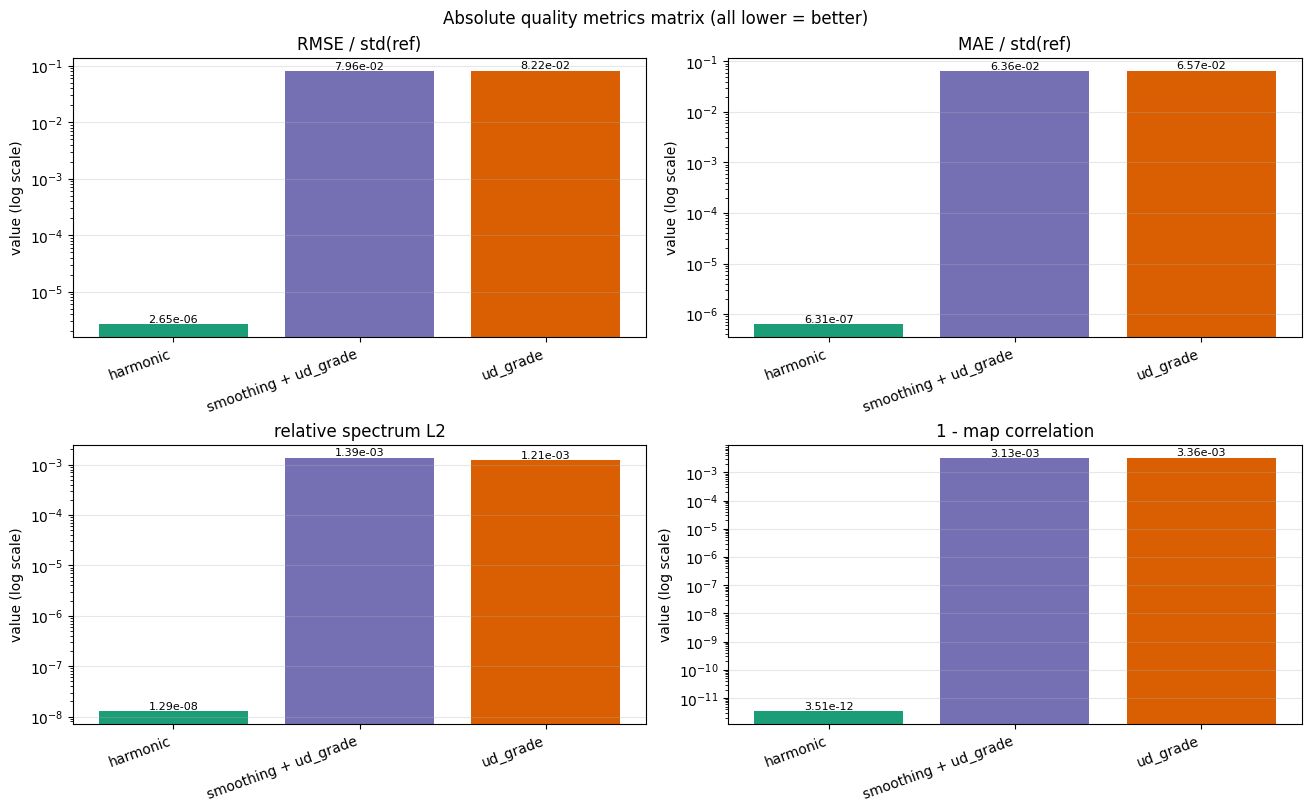

In [10]:
colors = ['#1b9e77', '#7570b3', '#d95f02']
x = np.arange(len(method_order))

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for ax, metric in zip(axes.flat, metric_order):
    values = np.array([metrics_plot[m][metric] for m in method_order], dtype=float)
    bars = ax.bar(x, values, color=colors)
    ax.set_yscale('log')
    ax.set_title(metric_labels[metric])
    ax.set_xticks(x, [method_labels[m] for m in method_order], rotation=20, ha='right')
    ax.set_ylabel('value (log scale)')
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2.0, v, f'{v:.2e}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Absolute quality metrics matrix (all lower = better)')
plt.show()

### Fractional spectrum difference vs reference

These two panels compare each downgraded spectrum to the synthetic target-NSIDE reference spectrum using `C_ell / C_ell^ref - 1`.

- The top panel shows the full multipole range.
- The bottom panel zooms to the high-`ell` end.
- In this realization, the fractional spectrum does **not** show a clean positive high-`ell` excess for `ud_grade`, so this panel should be read as a fidelity-to-reference comparison rather than a standalone aliasing proof.
- The evidence that `harmonic_ud_grade` is better in this synthetic test comes more clearly from the known-truth residual maps and the scalar metrics, where it stays much closer to the target-NSIDE reference map than `ud_grade`.

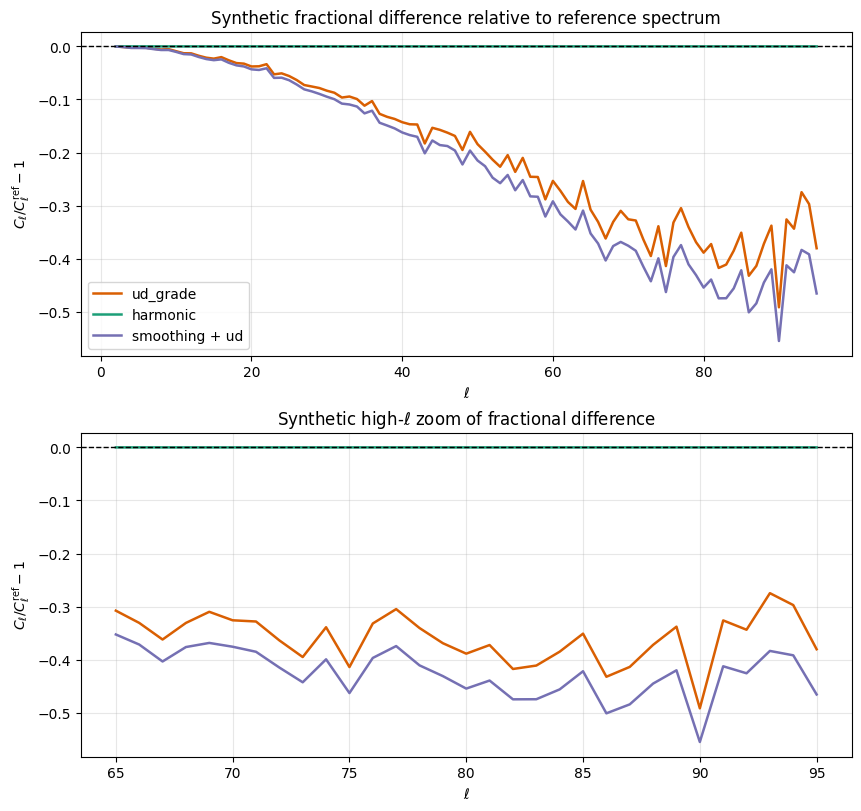

In [11]:
ell_zoom_min = max(2, lmax_out - 30)
good_all = ell_out >= 2
good_zoom = (ell_out >= ell_zoom_min) & (ell_out <= lmax_out)
comparisons = [
    ('ud_grade', cl_ud, '#d95f02'),
    ('harmonic', cl_harm, '#1b9e77'),
    ('smoothing + ud', cl_smooth_ud, '#7570b3'),
]

fig, axes = plt.subplots(2, 1, figsize=(8.5, 8.0), constrained_layout=True)
for label, cl_arr, color in comparisons:
    frac_all = cl_arr[good_all] / cl_ref[good_all] - 1.0
    frac_zoom = cl_arr[good_zoom] / cl_ref[good_zoom] - 1.0
    axes[0].plot(ell_out[good_all], frac_all, linewidth=1.8, label=label, color=color)
    axes[1].plot(ell_out[good_zoom], frac_zoom, linewidth=1.8, label=label, color=color)
for ax in axes:
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel(r'$C_\ell / C_\ell^{\mathrm{ref}} - 1$')
    ax.grid(alpha=0.3)
axes[0].set_title('Synthetic fractional difference relative to reference spectrum')
axes[0].set_xlabel(r'$\ell$')
axes[0].legend()
axes[1].set_title('Synthetic high-$\ell$ zoom of fractional difference')
axes[1].set_xlabel(r'$\ell$')
plt.show()

vmin=-37.0, vmax=37.0


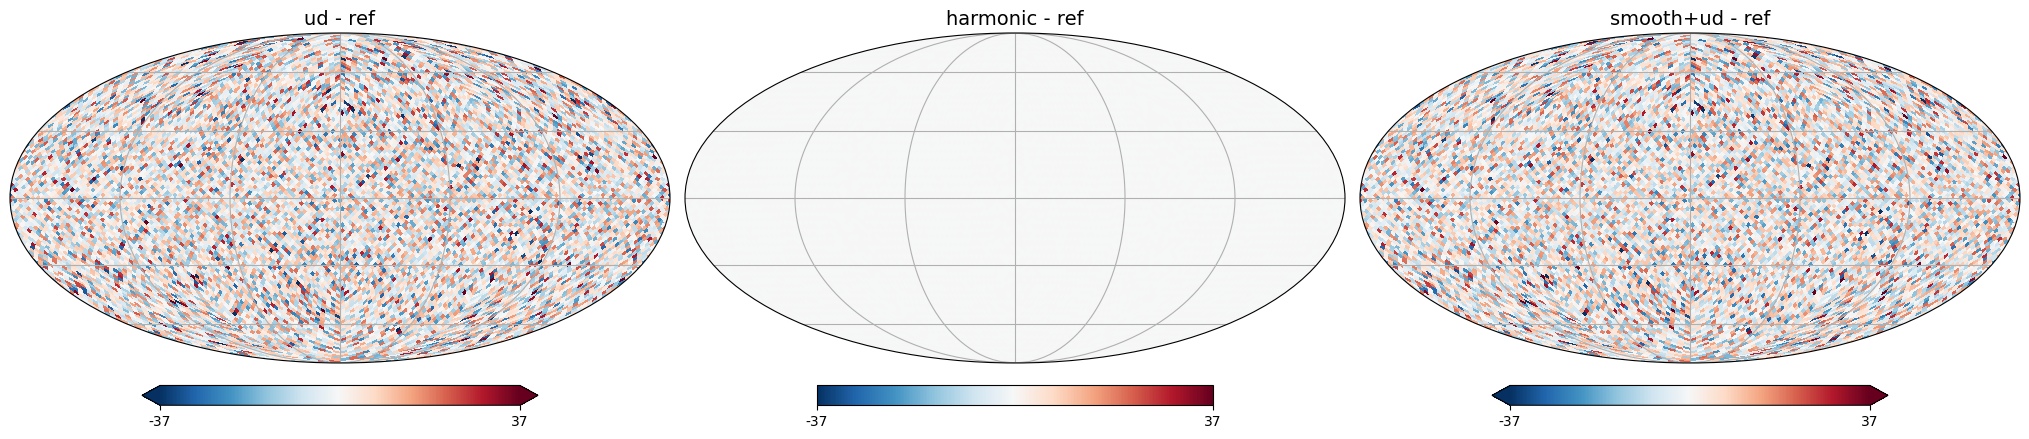

In [12]:
proj_panels(
    [m_ud - m_ref, m_harm - m_ref, m_smooth_ud - m_ref],
    ['ud - ref', 'harmonic - ref', 'smooth+ud - ref'],
    cmap='RdBu_r',
    q=(0.1, 99.9),
    symmetric=True,
)

### Synthetic Mollweide differences vs reference
Same residuals shown as Mollweide maps for direct visual comparison.


moll diff scale: vmin=-37.0, vmax=37.0


/tmp/ipykernel_12619/160289878.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


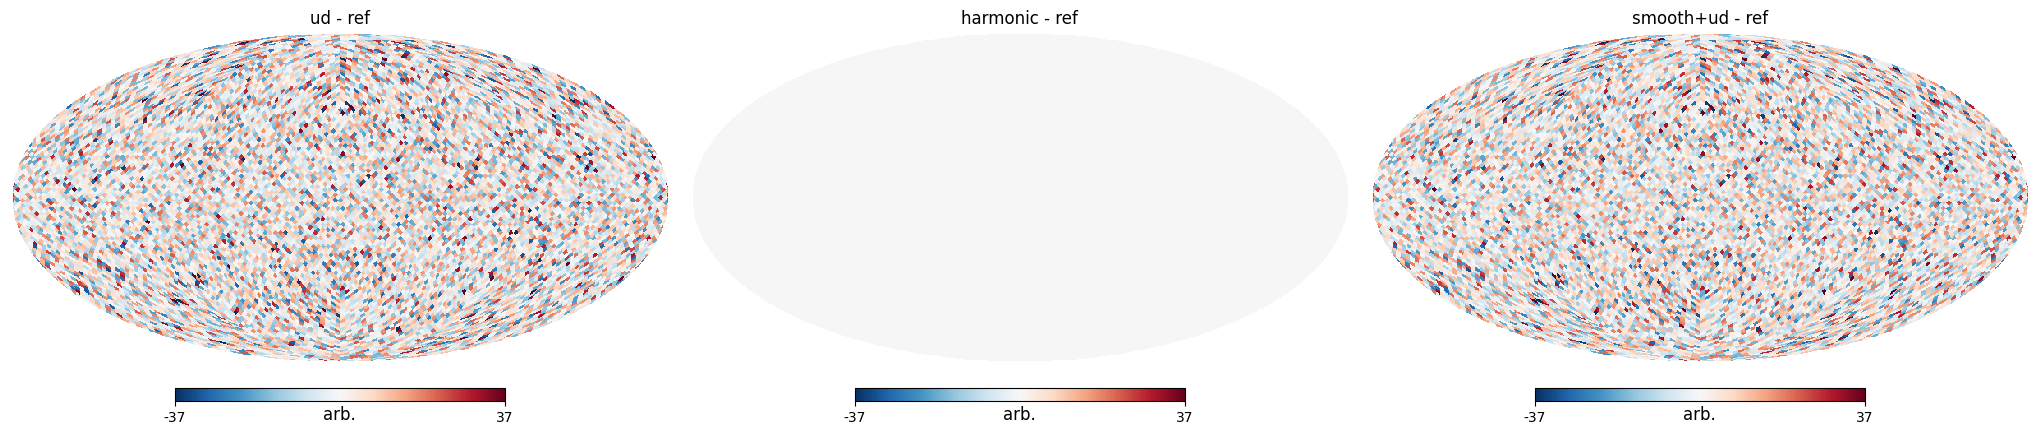

In [13]:
moll_diff_panels(
    [m_ud - m_ref, m_harm - m_ref, m_smooth_ud - m_ref],
    ['ud - ref', 'harmonic - ref', 'smooth+ud - ref'],
    unit='arb.',
    q=(0.1, 99.9),
)